In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import numpy as np


In [4]:
df=pd.read_csv("height-weight.csv")

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


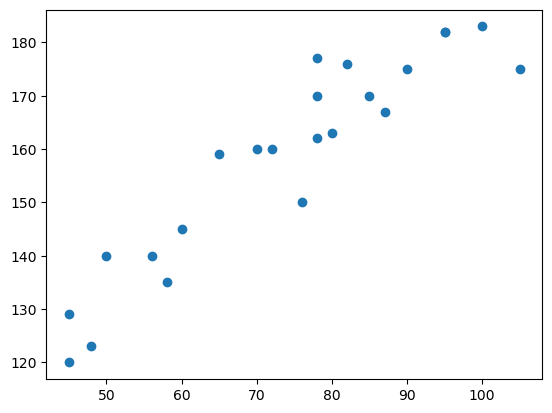

In [6]:
plt.scatter(df["Weight"],df["Height"])

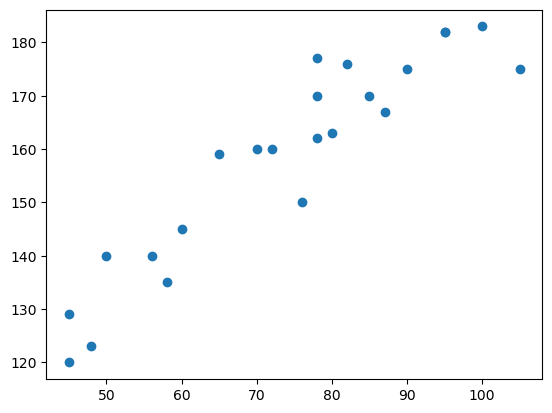

In [7]:
plt.scatter(x="Weight", y="Height", data=df)

In [8]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


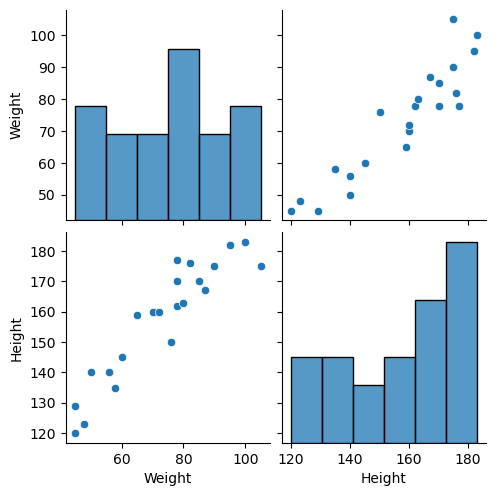

In [9]:
sns.pairplot(df)

In [10]:
# creating the indepented feature 
#indepented feature should be data frame or 2d array
x=df[["Weight"]]
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [11]:
type(x)

pandas.core.frame.DataFrame

In [12]:
# depentent feature can be series or 1d array
y=df["Height"]

In [13]:
# train test split
from sklearn.model_selection import train_test_split


In [14]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.25,random_state=40)

In [15]:
x_test.shape
# 17 are the rows and 1 indicate the number of feature 

(17, 1)

In [16]:
# standardization why means which feature u are using had big value so standization which is z test conert into mean=0 and standardizaion=value
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [17]:
x_train=scaler.fit_transform(x_train)

In [18]:
x_test=scaler.transform(x_test)
x_test
# why transform only because of data leakage the transfrom will mean and standard deviation train data only 

array([[ 1.15157703],
       [-2.68701308],
       [ 0.53740262],
       [-2.68701308],
       [-0.1535436 ],
       [ 0.38385901],
       [-2.30315407],
       [ 0.1535436 ],
       [-1.53543605],
       [-2.45669767],
       [-1.84252325],
       [ 1.91929506],
       [-1.68897965],
       [-0.30708721],
       [-0.1535436 ],
       [ 0.76771802],
       [ 0.        ]])

In [19]:
#apply linear regression 
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)


In [20]:
regression.fit(x_train,y_train)
print("coefficient or slope", regression.coef_)
print("inetrcept",regression.intercept_)


coefficient or slope [9.86517659]
inetrcept 170.16666666666666


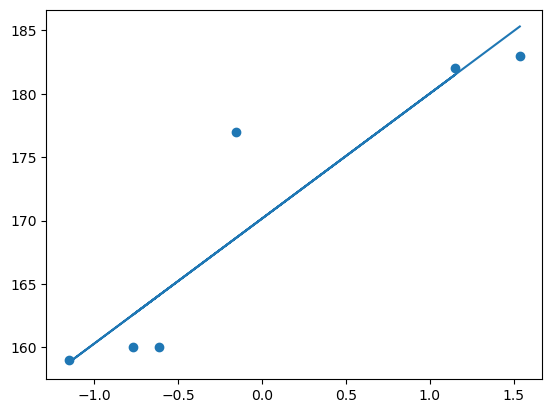

In [21]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [22]:
#prediction for test data
#predicted data= inetrcept+coeffiecient*(test data)
y_pred=regression.predict(x_test)

In [23]:
# performance matrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

155.65386537957315
10.327420162564039
12.47613182759677


In [24]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)

In [25]:
# ols linear regression
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()   # create model
model.fit(x_train, y_train)  # train model

prediction = model.predict(x_test)  # predict
print(prediction)

[181.52717747 143.65880812 175.46823838 143.65880812 168.65193189
 173.9535036  147.44564506 171.68140144 155.01931893 145.93091028
 151.98984938 189.10085134 153.50458415 167.13719712 168.65193189
 177.74034054 170.16666667]


In [28]:
import statsmodels.api as sm

# Fit OLS model (adding constant for intercept)
ols_model = sm.OLS(y_train, sm.add_constant(x_train)).fit()

# Print summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     23.62
Date:                Sun, 19 Apr 2026   Prob (F-statistic):            0.00828
Time:                        20:39:18   Log-Likelihood:                -16.921
No. Observations:                   6   AIC:                             37.84
Df Residuals:                       4   BIC:                             37.43
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        170.1667      2.030     83.825      0.0

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
#prediction of new value
new=regression.predict(scaler.transform([[75]])) # remenber of standardization the value you wanted to predict
print(new)


[166.37982973]


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
